# Operations on data with stat_tool

## This notebook illustates how to perform basic operations on data with stat_tool.data_transform

The main data structures in stat_tool are Vectors and Histogram. Histogram is basically a 1-D array or a multiset of integers, on which usually no particular methods are required since numpy offers many functions, except combining histograms with Merge.    
Operations on Vectors mainly consist in merging variables or individuals or shifting them.

## Transform data on Vectors

We first load a data set (chene_sessile.vec)    

In [1]:
from openalea.stat_tool import (get_shared_data,
                                Histogram
)
from openalea.stat_tool.data_transform import (SelectVariable, 
                                               SelectIndividual, 
                                               Merge,
                                               MergeVariable,
                                               Shift,
                                               ValueSelect
)
from openalea.stat_tool.output import Plot
from openalea.stat_tool.vectors import Vectors
from openalea.stat_tool.cluster import Transcode

vec = Vectors(get_shared_data("chene_sessile.vec"))

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


In [2]:
print(vec)

138 vectors

6 VARIABLES

VARIABLE 1 : INT   (minimum value: 1995, maximum value: 1997)

marginal frequency distribution - sample size: 138
mean: 1996   median: 1996   mode: 1996
variance: 0.671533   standard deviation: 0.819471   lower quartile: 1995   upper quartile: 1997

VARIABLE 2 : INT   (minimum value: 4, maximum value: 110)

marginal frequency distribution - sample size: 138
mean: 42.8043   median: 37   mode: 26
variance: 539.064   standard deviation: 23.2177   lower quartile: 24   upper quartile: 61

VARIABLE 3 : INT   (minimum value: 39, maximum value: 219)

marginal frequency distribution - sample size: 138
mean: 107.725   median: 102   mode: 85
variance: 1424.04   standard deviation: 37.7365   lower quartile: 84   upper quartile: 131

VARIABLE 4 : INT   (minimum value: 1, maximum value: 4)

marginal frequency distribution - sample size: 138
mean: 1.63768   median: 2   mode: 2
variance: 0.349519   standard deviation: 0.591201   lower quartile: 1   upper quartile: 2

   | fre

Note that vec2 contains 6 variables.    

### Selecting variables

We can select the first two variables using function SelectVariable:

In [3]:
vec2 = SelectVariable(vec, [1,2], "Keep")

This is equivalent to using the method Vectors.select_variable, except that the last argument is Keep in [True, False] instead of Mode in ["Keep", "Reject"].

In [4]:
assert(str(vec2) == str(vec.select_variable([1,2], True)))

We can check that only 2 variables are remaining:

In [5]:
vec2.nb_variable

2

Setting argument "Keep" to False would discard variables [1,2]:

In [6]:
assert(vec.select_variable([1,2], False).nb_variable == 4)

### Selecting individuals

In the same way we can select variables, we can also select individuals:

In [7]:
subvec = SelectIndividual(vec,list(range(30, 120)), "Keep")

...which is equivalent to 

In [8]:
assert(str(subvec) == str(vec.select_individual(list(range(30, 120)), True)))

### Merging Vectors

Vectors with the same dimension can be merged (individual-wise):

In [9]:
vec_i1 = Vectors([[0, 0, 0], [1, 1, 1]])
vec_i2 = Vectors([[2, 2, 2], [3, 3, 3]])
vec_i3 = Vectors([[4, 4, 4]])
vec_merged = Merge(vec_i1, vec_i2, vec_i3)
vec_merged.nb_vector

5

This is equivalent to using the method Vectors.merge:

In [10]:
str(vec_i1.merge([vec_i2, vec_i3])) == str(vec_merged)

False

In [11]:
print(vec_merged[4])

[4, 4, 4]


It can be seen that the last vector from the merge Vectors is the last vector from vec_i3.

Similarly, Vectors with the same numbers of individuals can be merged (variable-wise):

In [12]:
vec_v2 = Vectors([[5], [5], [5], [5], [5]])
vec_vmerged = MergeVariable(vec_merged, vec_v2, RefSample=1)

The RefSample argument is optional here and is used only to give identifiers to vectors using one of the samples as a reference, here sample 1.

In [13]:
print(vec_vmerged[0])

[0, 0, 0, 5]


It can be seen that the variable from vec_v2 has been added to the 3 variables from vec_merged.

This is equivalent to using the method Vectors.merge_variable:

In [14]:
print((vec_merged.merge_variable([vec_v2],1))[0])

[0, 0, 0, 5]


### Shifting Vectors

Shifting a vector is the operation consisting in adding a constant to each value of a variable:

In [15]:
print(vec2)

138 vectors

2 VARIABLES

VARIABLE 1 : INT   (minimum value: 1995, maximum value: 1997)

marginal frequency distribution - sample size: 138
mean: 1996   median: 1996   mode: 1996
variance: 0.671533   standard deviation: 0.819471   lower quartile: 1995   upper quartile: 1997

VARIABLE 2 : INT   (minimum value: 4, maximum value: 110)

marginal frequency distribution - sample size: 138
mean: 42.8043   median: 37   mode: 26
variance: 539.064   standard deviation: 23.2177   lower quartile: 24   upper quartile: 61

correlation matrix

           1          2
1          1  -0.223663
2  -0.223663          1

reference t-value: 1.97756   reference critical probability: 0.05
limit correlation coefficient: 0.167188

reference t-value: 2.61246   reference critical probability: 0.01
limit correlation coefficient: 0.218599



In [16]:
print(Shift(vec2, 1, 2))

138 vectors

2 VARIABLES

VARIABLE 1 : INT   (minimum value: 1997, maximum value: 1999)

marginal frequency distribution - sample size: 138
mean: 1998   median: 1998   mode: 1998
variance: 0.671533   standard deviation: 0.819471   lower quartile: 1997   upper quartile: 1999

VARIABLE 2 : INT   (minimum value: 4, maximum value: 110)

marginal frequency distribution - sample size: 138
mean: 42.8043   median: 37   mode: 26
variance: 539.064   standard deviation: 23.2177   lower quartile: 24   upper quartile: 61

correlation matrix

           1          2
1          1  -0.223663
2  -0.223663          1

reference t-value: 1.97756   reference critical probability: 0.05
limit correlation coefficient: 0.167188

reference t-value: 2.61246   reference critical probability: 0.01
limit correlation coefficient: 0.218599



Here, variable 1 (second argument) has been shifted by 2 (third argument).    
If a Vectors object has only one variable, the variable does not have to be passed as an argument:

In [17]:
Shift(vec_v2, 2)[0]

[7]

As usual, it is equivalent to use method Vectors.shift:

In [18]:
print([vec2.get_min_value(0), vec2.shift(1, 2).get_min_value(0)])

[1995.0, 1997.0]


Vectors can be shifted by negative values:

In [19]:
Shift(vec_i2, 1, -3)[0]

[-1, 2, 2]

### Selecting individuals by values (filtering individuals)

Individual vectors in Vectors can be selected or discarded according to their values.   
For example,

In [20]:
ValueSelect(vec_merged, 1, 2, 3).nb_vector

2

selects all vectors in vec_merged such that variable 1 is between 2 and 3.   
To discard all such vectors, use argument 'Mode = "Reject"':

In [21]:
ValueSelect(vec_merged, 1, 2, 3, Mode="Reject").nb_vector

3

The object-oriented syntax is:

In [22]:
vec_merged.value_select(1, 2, 3, True)

where the last argument corresponds to 'Keep=True'.

### Transcoding Vectors

Transcoding the values of a Vectors object consists in replacing a value by another one. To use function Transcode, the list of values that replace the former ones is placed as argument:

In [23]:
Transcode(vec_merged, 1, [0, -1, -2, -3, -4])

This is equivalent to using method Vectors.transcode:

In [24]:
print([vec_merged.transcode(1, [0, -1, -2, -3, -4])[i][0] for i in range(vec_merged.nb_vector)])

[0, -1, -2, -3, -4]


In [25]:
print([vec_merged[i][0] for i in range(vec_merged.nb_vector)])

[0, 1, 2, 3, 4]


Note that 0 has been replaced by 0, 1 by -1, etc.

## Transform data on Histograms

### Merging histograms

Histogram objects can be merged, which consists in adding counts of each histogram.   
It can be seen from y-axis in the last figure that counts match the sum of counts of the 2 previous figures.

In [26]:
meri1 = Histogram(get_shared_data("meri1.his"))
meri2 = Histogram(get_shared_data("meri2.his"))
meri12 = Merge(meri1, meri2)

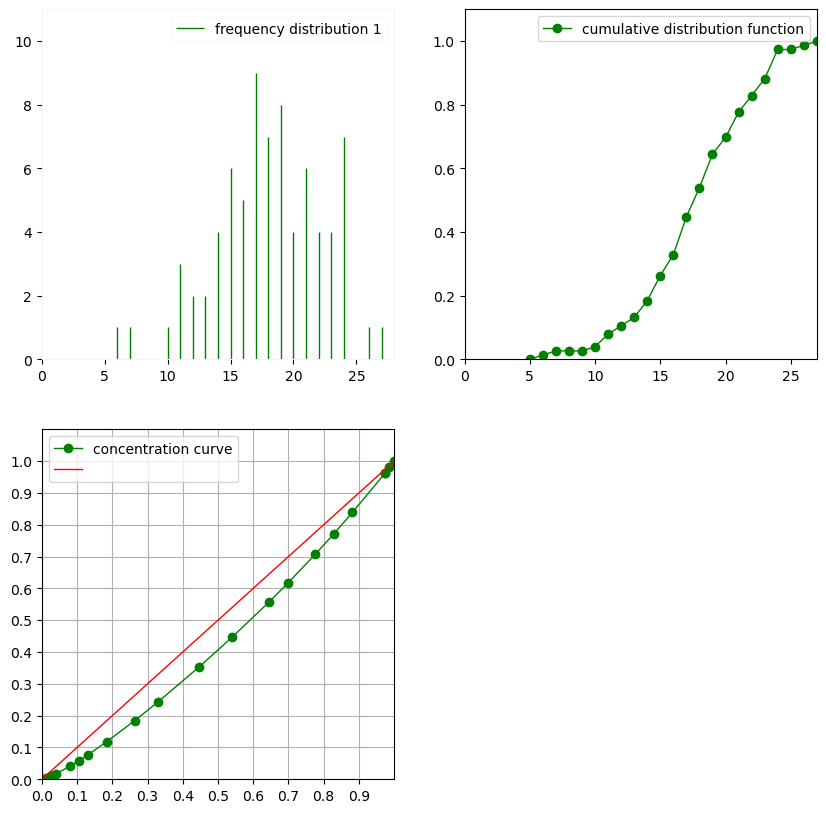

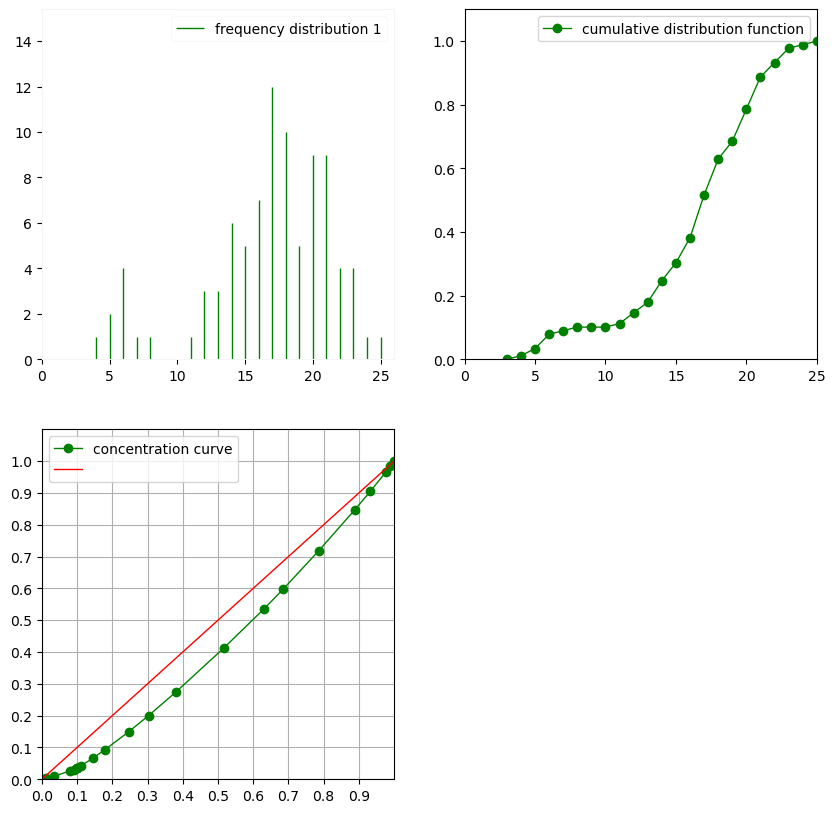

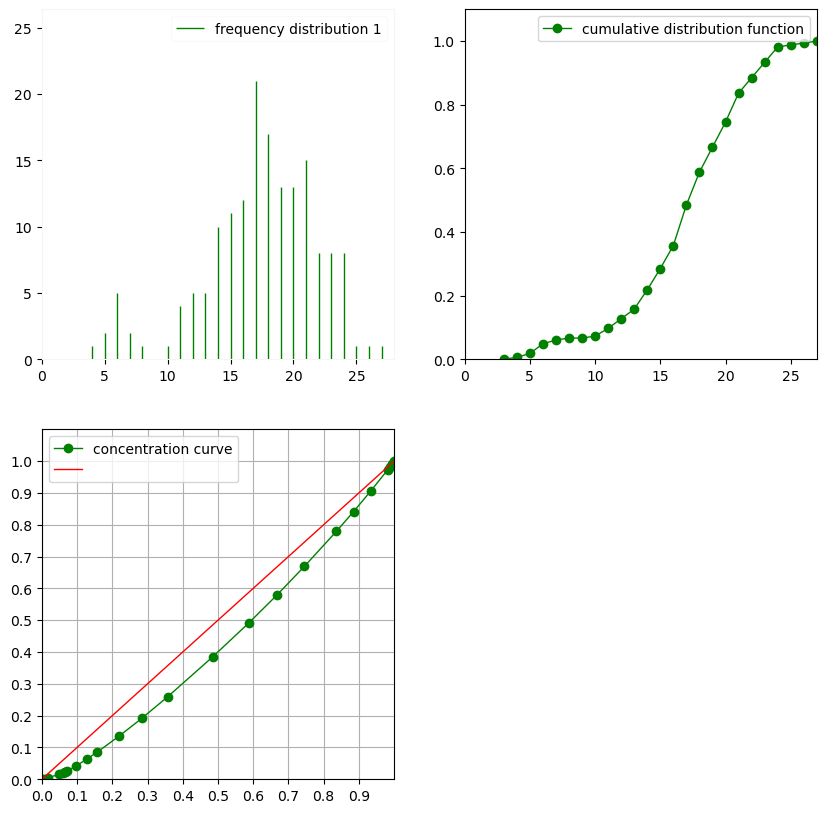

In [27]:
Plot(meri1)
Plot(meri2) 
Plot(meri12)

Arbitrary numbers of Histogram objects can be merged:

In [28]:
meri3 = Histogram(get_shared_data("meri3.his"))
meri123 = Merge(meri1, meri2, meri3)

This is equivalent to the method Histogram.merge:

In [29]:
meri123b = meri1.merge([meri2, meri3])
assert(str(meri123) == str(meri123b))

### Shifting histograms

As Vectors, Histogram objects can be shifted:

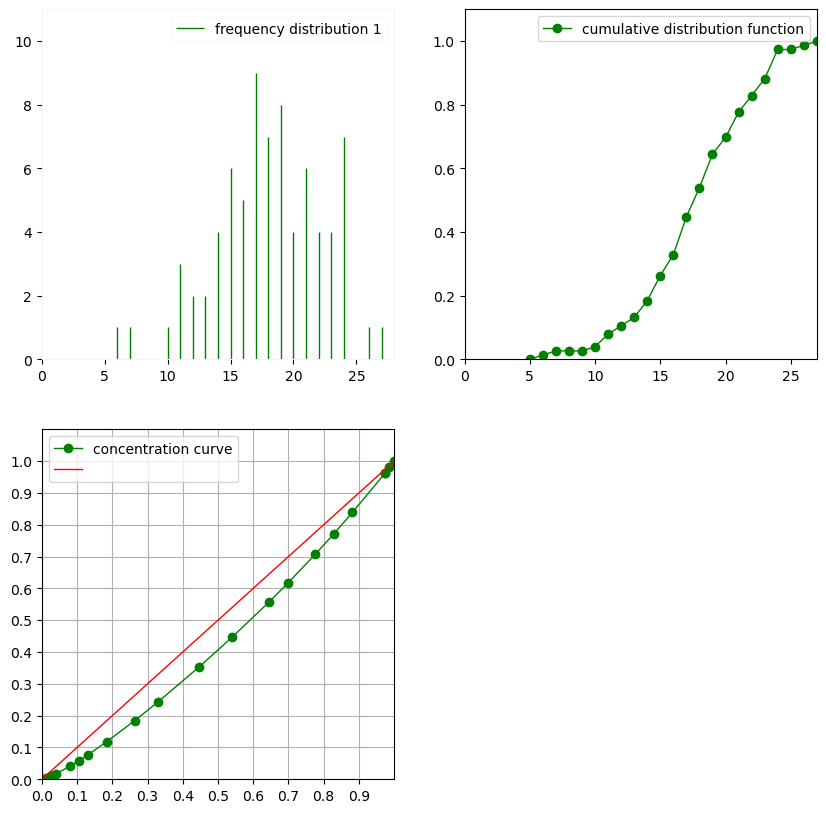

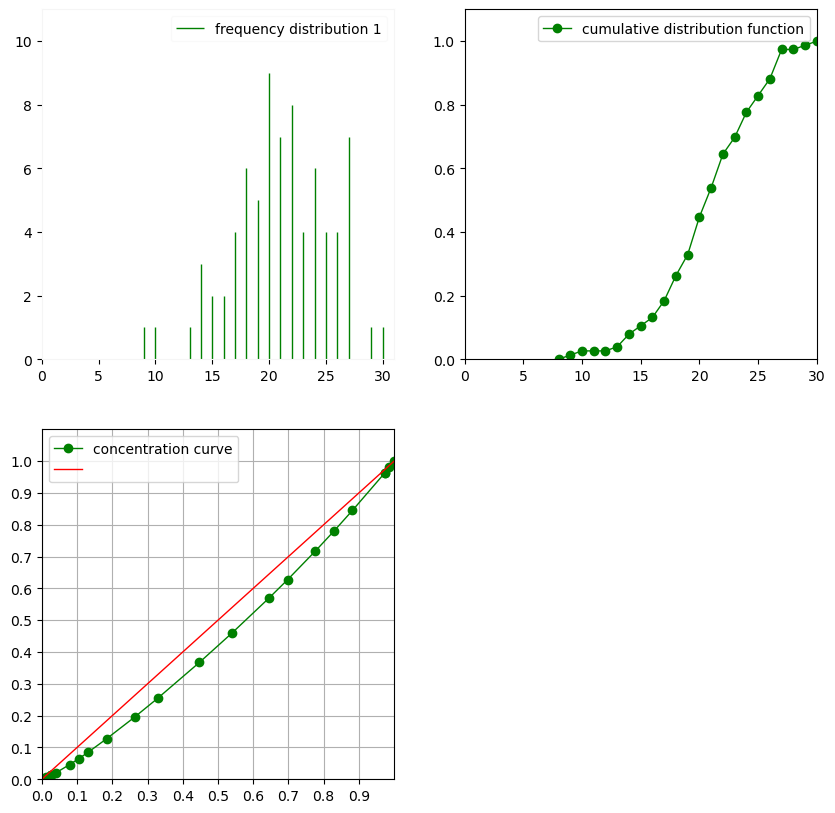

In [30]:
Plot(meri1)
Plot(Shift(meri1,3))

All values have been shifted by 3 (shift of the x-axis). This is equivalent to Histogram.shift:

In [31]:
assert(str(Shift(meri1,3)) == str(meri1.shift(3)))

### Selecting individuals by values (filtering histograms)

As Vectors, Histogram objects can be filtered:

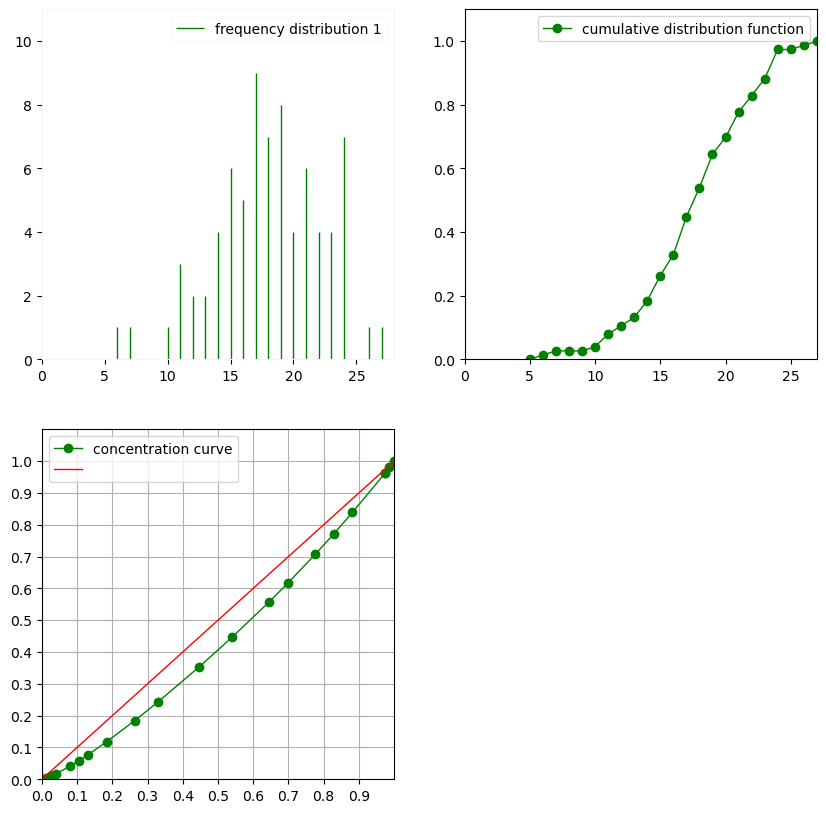

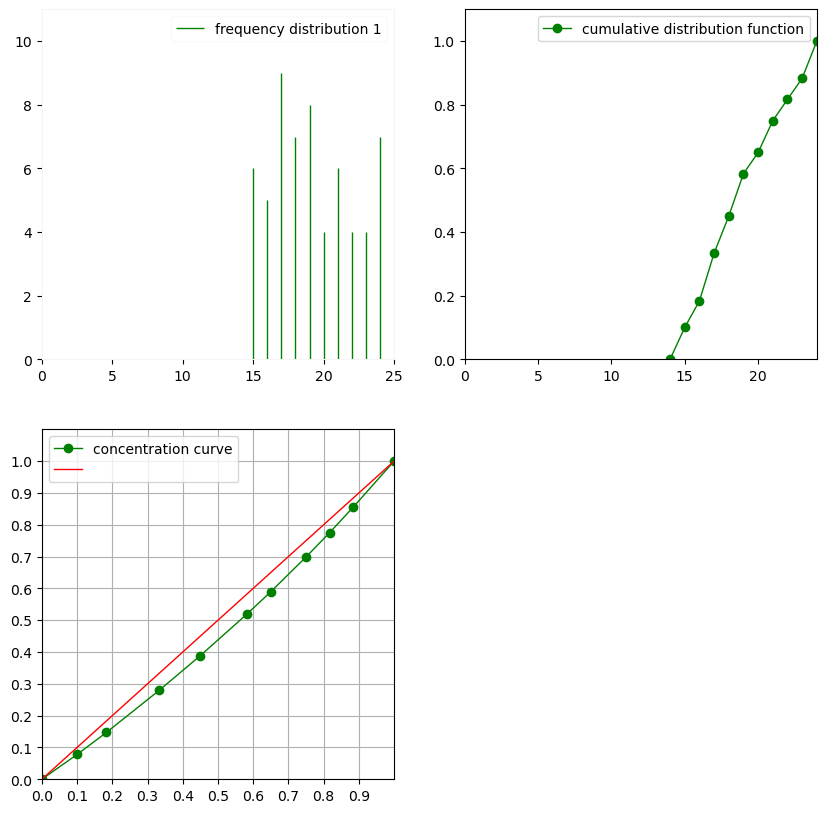

In [32]:
Plot(meri1)
Plot(ValueSelect(meri1,15,25))

Here, only the values between 15 and 25 have been selected. This is equivalent with Histogram.value_select

In [33]:
assert(str(ValueSelect(meri1,15,25)) == str(meri1.value_select(15,25,True)))

### Transcoding Histograms

As Vectors, the values of Histogram objects can be transcoded:


In [34]:
meri_vselect = Shift(ValueSelect(meri1,6,10),-6)
print(meri_vselect.display(Detail=2))

frequency distribution - sample size: 3
mean: 1.66667   median: 1   mode: 0.5
variance: 4.33333   standard deviation: 2.08167   lower quartile: 0   upper quartile: 4
coefficient of skewness: 1.29334   coefficient of kurtosis: -2
mean absolute deviation: 1.55556   coefficient of concentration: 0.533333
information: -3.29584 (-1.09861)

   | frequency distribution | cumulative distribution function
0  1  0.333333
1  1  0.666667
2  0  0.666667
3  0  0.666667
4  1         1



# TODO: check syntax

meri_transcoded = Transcode(meri1,[0, 1, 2, 3, 4])
print(meri_transcoded.display(Detail=2))